In [1]:
import sys, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

In [2]:
mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()
print(f"Data shape: {data.shape}")
print(f"Labels shape (before one-hot): {labels.shape}")

Loaded cached data from ../../data/processed/melspec_cache.npz
Data shape: (14975, 150, 150, 1)
Labels shape (before one-hot): (14975,)


In [3]:
labels = mgr.one_hot()
print(f"Labels shape (one-hot): {labels.shape}")

Labels shape (one-hot): (14975, 10)


In [4]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (11980, 150, 150, 1)
X_test shape: (2995, 150, 150, 1)
Y_train shape: (11980, 10)
Y_test shape: (2995, 10)


In [5]:
# Konwersja na RGB (MobileNetV2 wymaga 3 kanałów)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)
print(f"Przed RGB: {X_train.shape}")
print(f"Po RGB: {X_train_rgb.shape}")

Przed RGB: (11980, 150, 150, 1)
Po RGB: (11980, 150, 150, 3)


In [6]:
base_model = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
# output = layers.Dense(10, activation='softmax')(x)
output = layers.Dense(10, activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\piotr\AppData\Local\Temp\ipykernel_27004\1029975692.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
history = model.fit(
    X_train_rgb, Y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 88s 164ms/step - accuracy: 0.4786 - loss: 1.4907 - val_accuracy: 0.6027 - val_loss: 1.1735
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 50s 165ms/step - accuracy: 0.6010 - loss: 1.1623 - val_accuracy: 0.6477 - val_loss: 1.0322
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 164ms/step - accuracy: 0.6372 - loss: 1.0554 - val_accuracy: 0.6736 - val_loss: 0.9539
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 48s 161ms/step - accuracy: 0.6627 - loss: 0.9779 - val_accuracy: 0.6757 - val_loss: 0.9350
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 48s 162ms/step - accuracy: 0.6659 - loss: 0.9430 - val_accuracy: 0.6903 - val_loss: 0.8795
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 163ms/step - accuracy: 0.6853 - loss: 0.8909 - val_accuracy: 0.6912 - val_loss: 0.8665
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 51s 169ms/step - accuracy: 0.6938 - loss: 0.8531 - val_accuracy: 0.7062 - val_loss: 0.8634
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 162ms/step - accuracy: 0.7054 - loss: 0

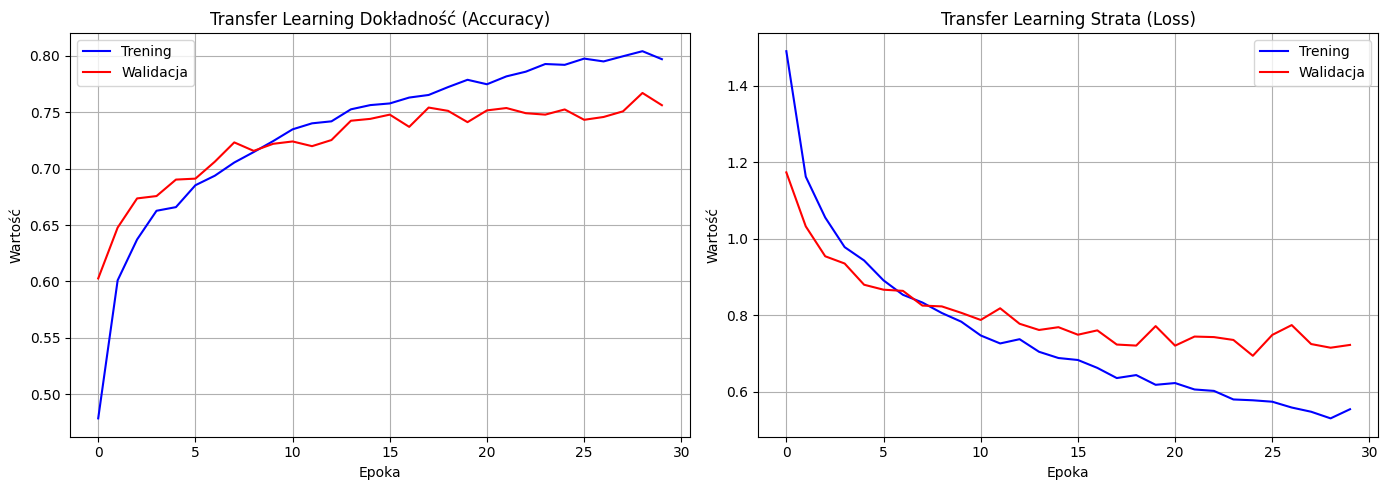

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Trening', color='blue')
ax1.plot(val_acc, label='Walidacja', color='red')
ax1.set_title('Transfer Learning Dokładność (Accuracy)')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Wartość')
ax1.legend()
ax1.grid(True)

ax2.plot(loss, label='Trening', color='blue')
ax2.plot(val_loss, label='Walidacja', color='red')
ax2.set_title('Transfer Learning Strata (Loss)')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Wartość')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Ewaluacja na zbiorze testowym
test_loss, test_acc = model.evaluate(X_test_rgb, Y_test, verbose=1)
print(f"\nDokładność na zbiorze testowym: {test_acc:.2%}")
print(f"Strata na zbiorze testowym: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.7723 - loss: 0.7098

Dokładność na zbiorze testowym: 77.23%
Strata na zbiorze testowym: 0.7098


94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step


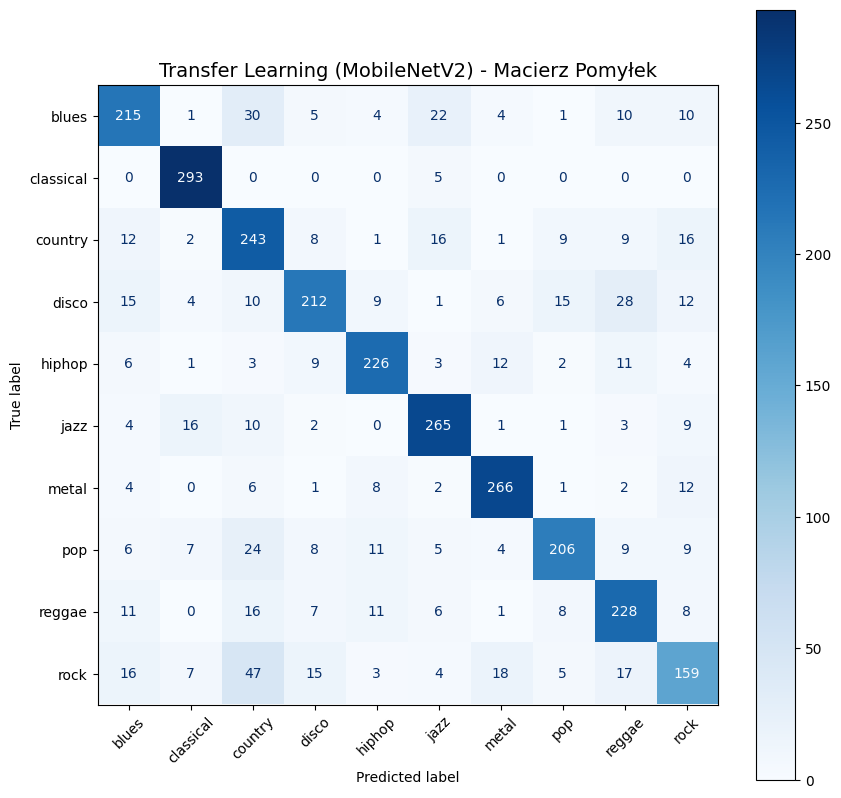


Raport klasyfikacji:
              precision    recall  f1-score   support

       blues       0.74      0.71      0.73       302
   classical       0.89      0.98      0.93       298
     country       0.62      0.77      0.69       317
       disco       0.79      0.68      0.73       312
      hiphop       0.83      0.82      0.82       277
        jazz       0.81      0.85      0.83       311
       metal       0.85      0.88      0.87       302
         pop       0.83      0.71      0.77       289
      reggae       0.72      0.77      0.74       296
        rock       0.67      0.55      0.60       291

    accuracy                           0.77      2995
   macro avg       0.77      0.77      0.77      2995
weighted avg       0.77      0.77      0.77      2995



In [10]:
Y_pred_proba = model.predict(X_test_rgb)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)

cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Transfer Learning (MobileNetV2) - Macierz Pomyłek', fontsize=14)
plt.xticks(rotation=45)
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(Y_true_classes, Y_pred_classes, target_names=classes))

In [11]:
model.save('../models/Transfer_learning.keras')
print("Model zapisany jako: ../models/Transfer_learning.keras")

Model zapisany jako: ../models/Transfer_learning.keras


In [15]:
# Fine-tuning (opcjonalnie - odmrożenie części warstw bazowych)
print("Rozpoczynam fine-tuning...")

# Odmroź ostatnie 30 warstw
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Rekompiluj z mniejszą learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Dotrenuj
history_fine = model.fit(
    X_train_rgb, Y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Rozpoczynam fine-tuning...
Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 81s 226ms/step - accuracy: 0.4554 - loss: 2.2183 - val_accuracy: 0.7283 - val_loss: 0.8276
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 61s 202ms/step - accuracy: 0.5521 - loss: 1.4277 - val_accuracy: 0.7154 - val_loss: 0.9113
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 51s 169ms/step - accuracy: 0.6188 - loss: 1.1215 - val_accuracy: 0.7108 - val_loss: 0.9343
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 52s 172ms/step - accuracy: 0.6479 - loss: 1.0181 - val_accuracy: 0.7095 - val_loss: 0.9225
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 52s 175ms/step - accuracy: 0.6826 - loss: 0.9081 - val_accuracy: 0.7166 - val_loss: 0.8918
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 53s 176ms/step - accuracy: 0.7062 - loss: 0.8294 - val_accuracy: 0.7158 - val_loss: 0.8619
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/step - accuracy: 0.7328 - loss: 0.7704 - val_accuracy: 0.7220 - val_loss: 0.8393
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 53s 178ms/step -

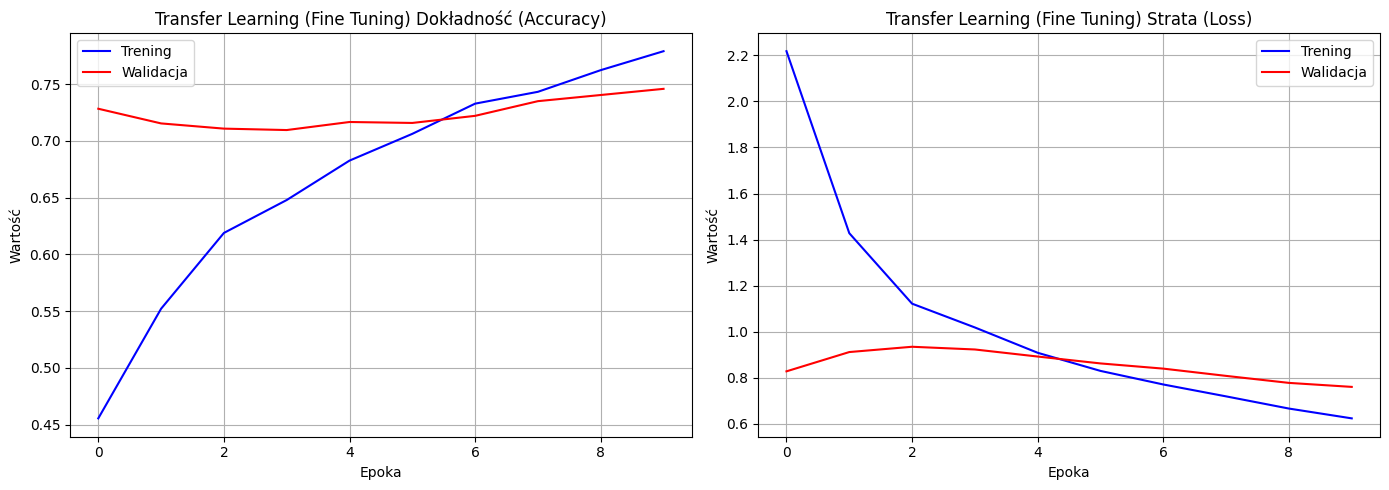

In [16]:
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Trening', color='blue')
ax1.plot(val_acc, label='Walidacja', color='red')
ax1.set_title('Transfer Learning (Fine Tuning) Dokładność (Accuracy)')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Wartość')
ax1.legend()
ax1.grid(True)

ax2.plot(loss, label='Trening', color='blue')
ax2.plot(val_loss, label='Walidacja', color='red')
ax2.set_title('Transfer Learning (Fine Tuning) Strata (Loss)')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Wartość')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [17]:
# # Ewaluacja po fine-tuningu
test_loss_fine, test_acc_fine = model.evaluate(X_test_rgb, Y_test, verbose=1)
print(f"\nDokładność po fine-tuningu: {test_acc_fine:.2%}")
print(f"Strata po fine-tuningu: {test_loss_fine:.4f}")
print(f"Poprawa: {(test_acc_fine - test_acc)*100:.2f} punktów procentowych")

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.7616 - loss: 0.7151

Dokładność po fine-tuningu: 76.16%
Strata po fine-tuningu: 0.7151
Poprawa: -1.07 punktów procentowych


94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step


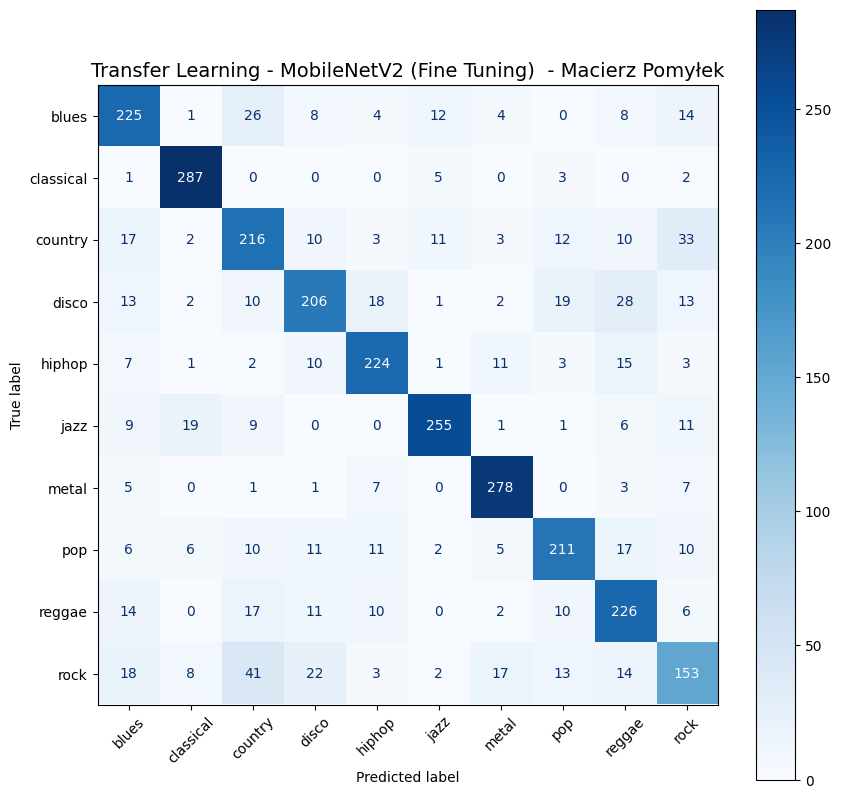


Raport klasyfikacji:
              precision    recall  f1-score   support

       blues       0.71      0.75      0.73       302
   classical       0.88      0.96      0.92       298
     country       0.65      0.68      0.67       317
       disco       0.74      0.66      0.70       312
      hiphop       0.80      0.81      0.80       277
        jazz       0.88      0.82      0.85       311
       metal       0.86      0.92      0.89       302
         pop       0.78      0.73      0.75       289
      reggae       0.69      0.76      0.73       296
        rock       0.61      0.53      0.56       291

    accuracy                           0.76      2995
   macro avg       0.76      0.76      0.76      2995
weighted avg       0.76      0.76      0.76      2995



In [18]:
Y_pred_proba = model.predict(X_test_rgb)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)

cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Transfer Learning - MobileNetV2 (Fine Tuning)  - Macierz Pomyłek', fontsize=14)
plt.xticks(rotation=45)
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(Y_true_classes, Y_pred_classes, target_names=classes))

In [19]:
# Zapisz model
model.save('../models/Transfer_learning_fine_tuning.keras')
print("Model zapisany jako: ../models/Transfer_learning_fine_tuning.keras")

Model zapisany jako: ../models/Transfer_learning_fine_tuning.keras
